## Imports


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
plt.style.use("seaborn-v0_8")
sns.set_theme(palette="deep")

In [3]:
PROCESSED_DATA_PATH: str = "../../mock-cloud/storage/data/processed"

## Attrition Dataset - EDA


In [4]:
df = pd.read_parquet(
    f"{PROCESSED_DATA_PATH}/employee_attrition_processed.parquet"
)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Department         14999 non-null  str    
 1   Salary             14999 non-null  str    
 2   ActiveProjects     14999 non-null  uint8  
 3   AvgMonthlyHours    14999 non-null  uint16 
 4   YearsAtCompany     14999 non-null  uint8  
 5   WorkAccidents      14999 non-null  bool   
 6   ReceivedPromotion  14999 non-null  bool   
 7   LastEvaluation     14999 non-null  float32
 8   SatisfactionScore  14999 non-null  float32
 9   Attrition          14999 non-null  bool   
dtypes: bool(3), float32(2), str(2), uint16(1), uint8(2)
memory usage: 626.1 KB


In [6]:
df.head()

,Department,Salary,ActiveProjects,AvgMonthlyHours,YearsAtCompany,WorkAccidents,ReceivedPromotion,LastEvaluation,SatisfactionScore,Attrition
0,sales,low,2,157,3,False,False,0.53,0.38,True
1,sales,medium,5,262,6,False,False,0.86,0.80,True
2,sales,medium,7,272,4,False,False,0.88,0.11,True
3,sales,low,5,223,5,False,False,0.87,0.72,True
4,sales,low,2,159,3,False,False,0.52,0.37,True


In [7]:
pd.Series({
    "duplicate_rows": df.duplicated().sum(),
    "attrition_rate": df["Attrition"].mean(),
}).round(2)

duplicate_rows    3008.00
attrition_rate       0.24
dtype: float64

In [8]:
pd.DataFrame({
    "unique_values": df.nunique(),
    "sample_values": [df[col].drop_duplicates().astype(str).sort_values().head(5).tolist() for col in df.columns],
})

,unique_values,sample_values
Department,10,"[IT, accounting, engineering, hr, management]"
Salary,3,"[high, low, medium]"
ActiveProjects,6,"[2, 3, 4, 5, 6]"
AvgMonthlyHours,215,"[100, 101, 102, 103, 104]"
YearsAtCompany,8,"[10, 2, 3, 4, 5]"
WorkAccidents,2,"[False, True]"
ReceivedPromotion,2,"[False, True]"
LastEvaluation,65,"[0.36, 0.37, 0.38, 0.39, 0.4]"
SatisfactionScore,92,"[0.09, 0.1, 0.11, 0.12, 0.13]"
Attrition,2,"[False, True]"


This dataset is complete at the feature level: there are no missing values, so any modeling caveats come from signal quality and pattern shape rather than incomplete data.


### Overall Distributions


In [9]:
df.describe().T.assign(range=lambda x: x["max"] - x["min"]).round(2)

,count,mean,std,min,25%,50%,75%,max,range
ActiveProjects,14999.0,3.80,1.23,2.00,3.00,4.00,5.00,7.0,5.00
AvgMonthlyHours,14999.0,201.05,49.94,96.00,156.00,200.00,245.00,310.0,214.00
YearsAtCompany,14999.0,3.50,1.46,2.00,3.00,3.00,4.00,10.0,8.00
LastEvaluation,14999.0,0.72,0.17,0.36,0.56,0.72,0.87,1.0,0.64
SatisfactionScore,14999.0,0.61,0.25,0.09,0.44,0.64,0.82,1.0,0.91


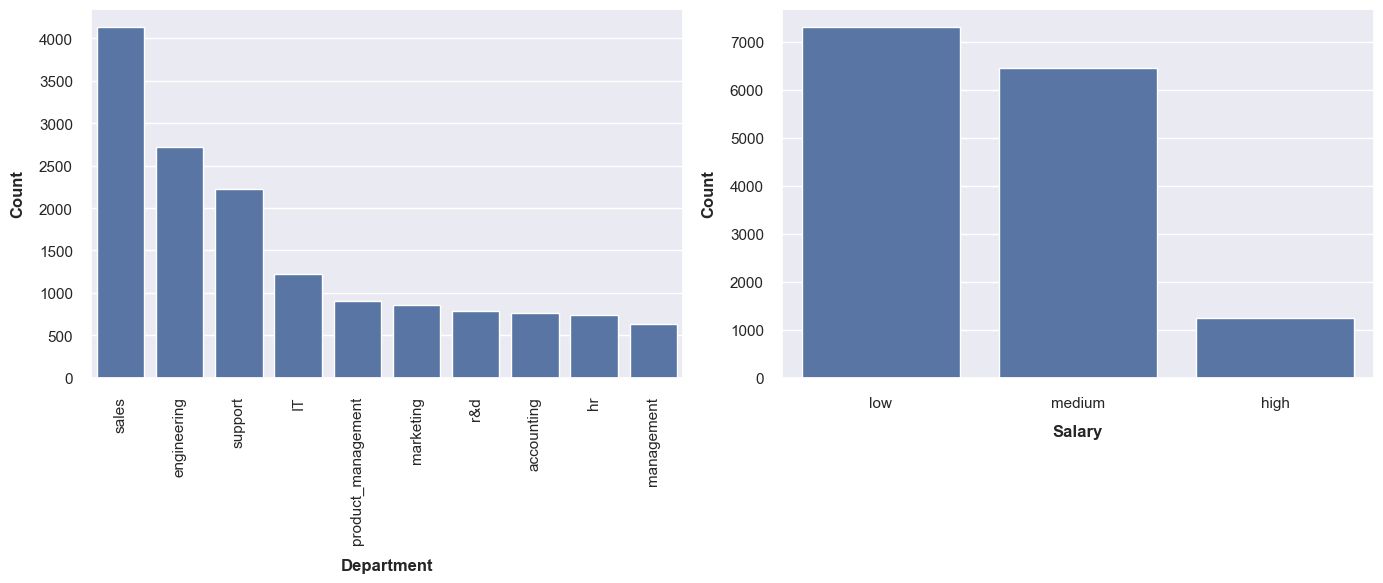

In [10]:
_, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(data=df.Department.value_counts(), ax=axes[0])
sns.barplot(data=df.Salary.value_counts(), ax=axes[1])

axes[0].tick_params(axis="x", rotation=90)
axes[0].set_xlabel("Department", fontweight="bold", labelpad=10)
axes[0].set_ylabel("Count", fontweight="bold", labelpad=10)

axes[1].set_xlabel("Salary", fontweight="bold", labelpad=10)
axes[1].set_ylabel("Count", fontweight="bold", labelpad=10)

plt.tight_layout()
plt.show()

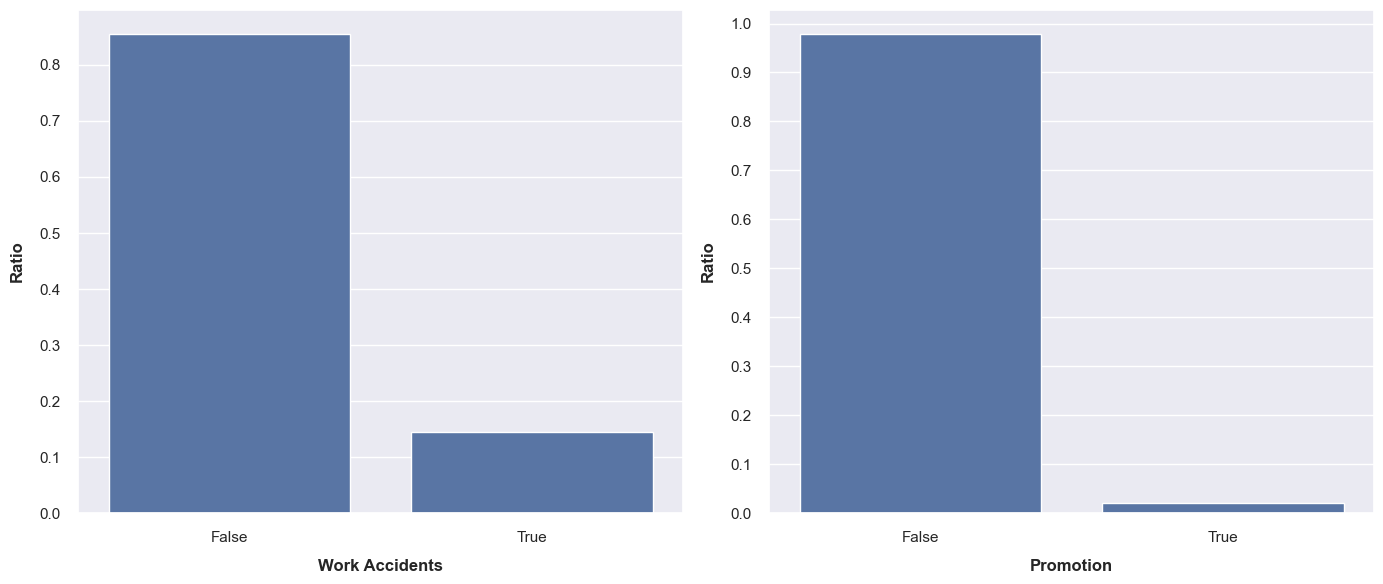

In [11]:
_, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(df.WorkAccidents.value_counts(normalize=True), ax=axes[0])
sns.barplot(df.ReceivedPromotion.value_counts(normalize=True), ax=axes[1])

axes[0].set_xlabel("Work Accidents", fontweight="bold", labelpad=10)
axes[0].set_ylabel("Ratio", fontweight="bold", labelpad=10)

axes[1].set_xlabel("Promotion", fontweight="bold", labelpad=10)
axes[1].set_ylabel("Ratio", fontweight="bold", labelpad=10)

for ax in axes:
    ax.yaxis.set_major_locator(plt.MultipleLocator(0.1))

plt.tight_layout()
plt.show()

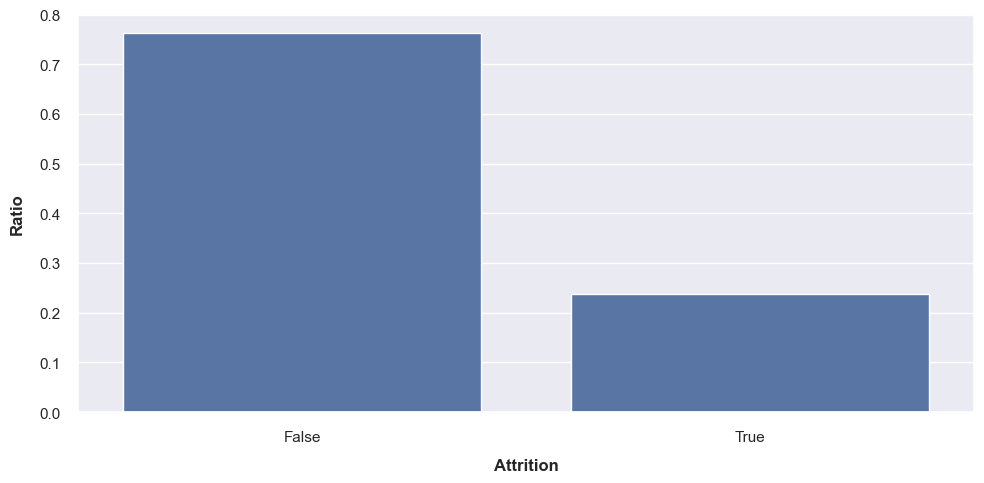

In [12]:
plt.figure(figsize=(10, 5))

ax = sns.barplot(df.Attrition.value_counts(normalize=True))
ax.set_xlabel("Attrition", fontweight="bold", labelpad=10)
ax.set_ylabel("Ratio", fontweight="bold", labelpad=10)

plt.tight_layout()
plt.show()

Attrition is moderately imbalanced at roughly one employee out of 4 leaving. That matters for train/test splitting and evaluation, but it is not severe enough to explain away weak linear correlations on its own.


### Attrition By Feature


In [13]:
def attrition_summary(df: pd.DataFrame, col: str) -> pd.DataFrame:
    summary = (
        df.groupby(col)["Attrition"]
        .agg(attrition_rate="mean", sample_size="size")
        .reset_index()
    )

    summary = summary.sort_values(["attrition_rate", "sample_size"], ascending=[False, False])

    return summary

In [ ]:
categorical_features = ["Department", "Salary", "WorkAccidents", "ReceivedPromotion"]

for col in categorical_features:
    display(attrition_summary(df, col).round(2))

,Department,attrition_rate,sample_size
3,hr,0.29,739
1,accounting,0.27,767
2,engineering,0.26,2720
9,support,0.25,2229
8,sales,0.24,4140
5,marketing,0.24,858
0,IT,0.22,1227
6,product_management,0.22,902
7,r&d,0.15,787
4,management,0.14,630


,Salary,attrition_rate,sample_size
1,low,0.30,7316
2,medium,0.20,6446
0,high,0.07,1237


,WorkAccidents,attrition_rate,sample_size
0,False,0.27,12830
1,True,0.08,2169


,ReceivedPromotion,attrition_rate,sample_size
0,False,0.24,14680
1,True,0.06,319


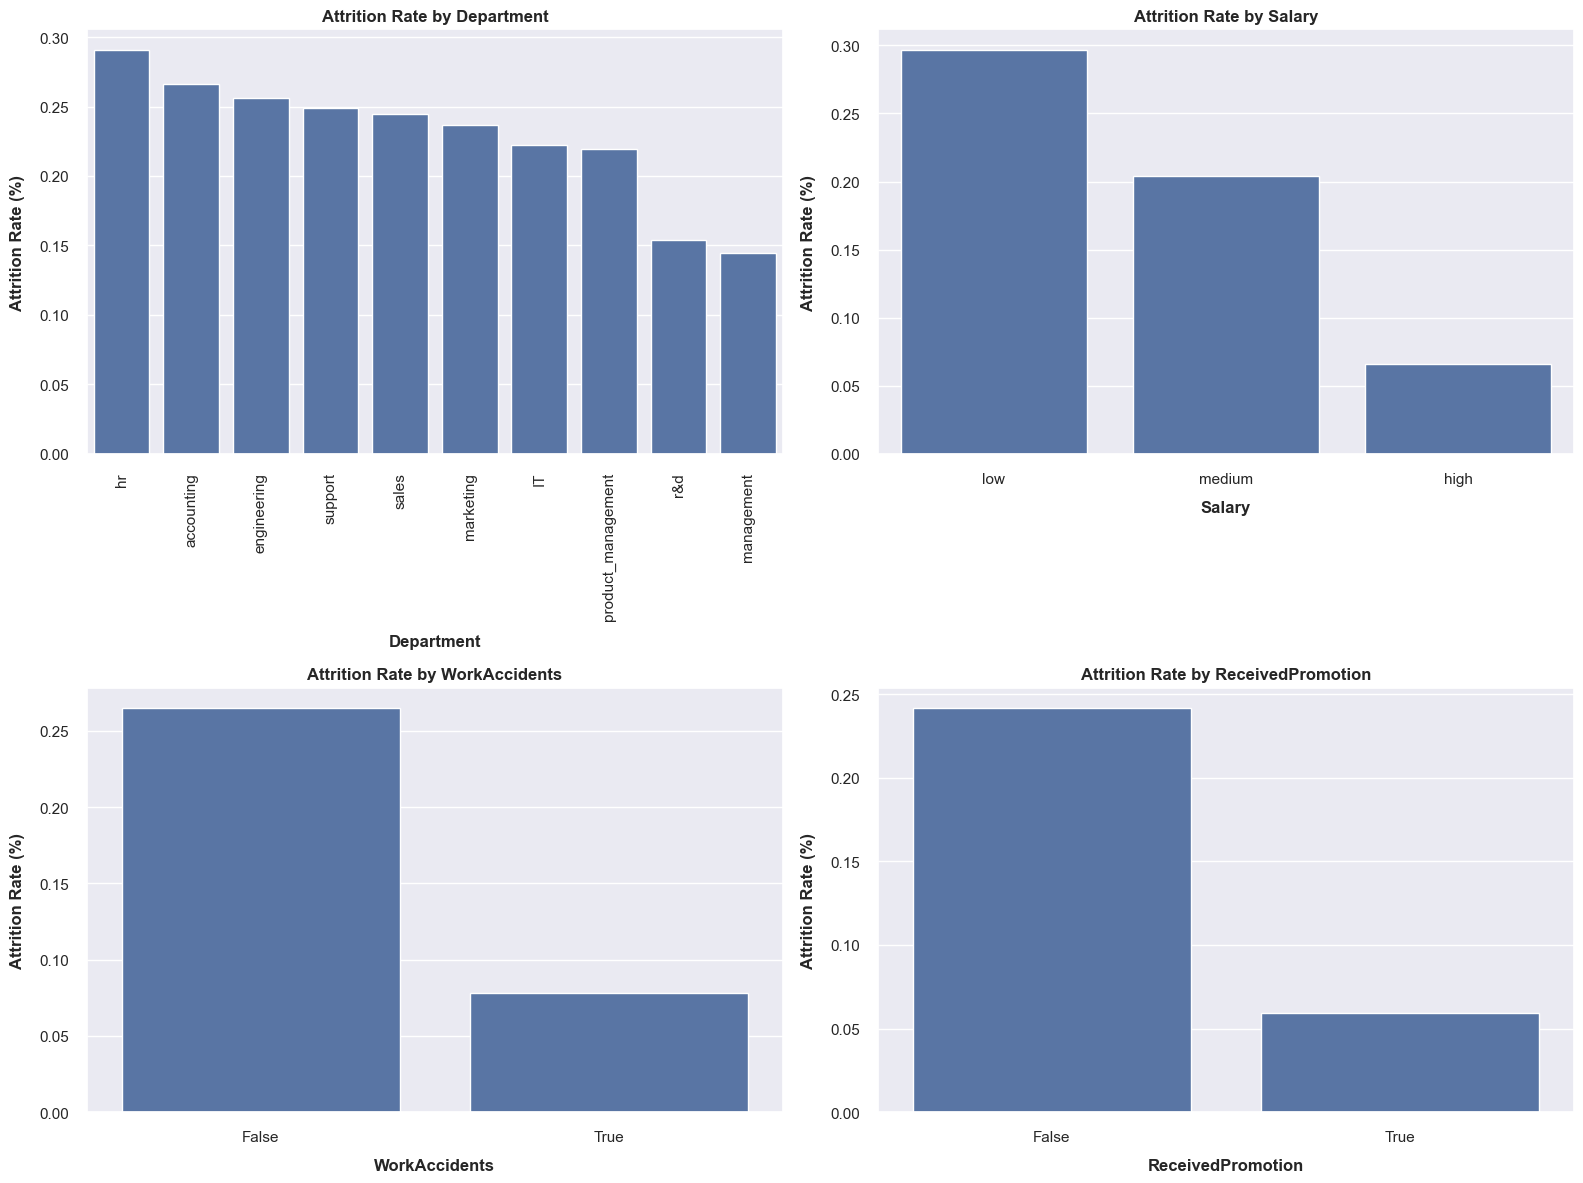

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

plot_config = [
    ("Department", axes[0, 0], True),
    ("Salary", axes[0, 1], False),
    ("WorkAccidents", axes[1, 0], False),
    ("ReceivedPromotion", axes[1, 1], False),
]

for col, ax, rotate in plot_config:
    summary = attrition_summary(df, col)
    sns.barplot(data=summary, x=col, y="attrition_rate", ax=ax)
    ax.set_xlabel(col, fontweight="bold", labelpad=10)
    ax.set_ylabel("Attrition Rate (%)", fontweight="bold", labelpad=10)
    ax.set_title(f"Attrition Rate by {col}", fontweight="bold")
    if rotate:
        ax.tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()

In [16]:
discrete_features = ["ActiveProjects", "YearsAtCompany"]

for col in discrete_features:
    display(attrition_summary(df, col).round(2))

,ActiveProjects,attrition_rate,sample_size
5,7,1.00,256
0,2,0.66,2388
4,6,0.56,1174
3,5,0.22,2761
2,4,0.09,4365
1,3,0.02,4055


,YearsAtCompany,attrition_rate,sample_size
3,5,0.57,1473
2,4,0.35,2557
4,6,0.29,718
1,3,0.25,6443
0,2,0.02,3244
7,10,0.00,214
5,7,0.00,188
6,8,0.00,162


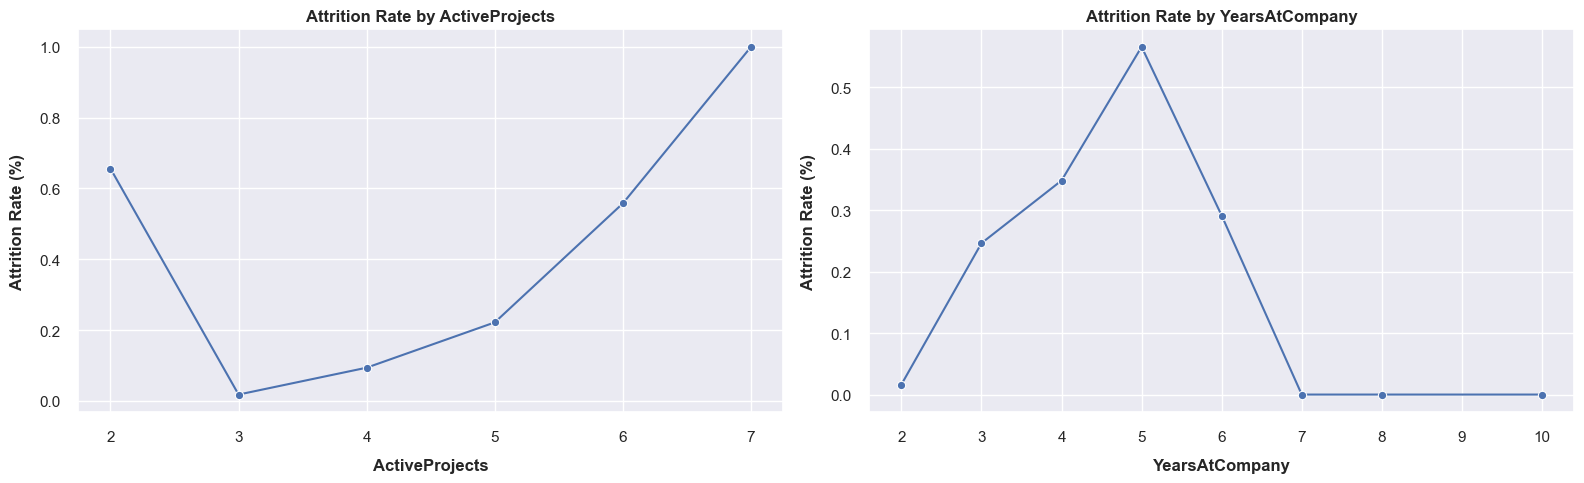

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for col, ax in zip(["ActiveProjects", "YearsAtCompany"], axes):
    summary = attrition_summary(df, col)
    sns.lineplot(data=summary, x=col, y="attrition_rate", marker="o", ax=ax)
    ax.set_xlabel(col, fontweight="bold", labelpad=10)
    ax.set_ylabel("Attrition Rate (%)", fontweight="bold", labelpad=10)
    ax.set_title(f"Attrition Rate by {col}", fontweight="bold")

plt.tight_layout()
plt.show()

Several features show meaningful target separation once we condition on attrition rather than looking only at marginal distributions. Salary, promotion history, workplace accidents, projects, and tenure all shift the attrition rate in visible ways.


### Distribution Comparisons By Attrition


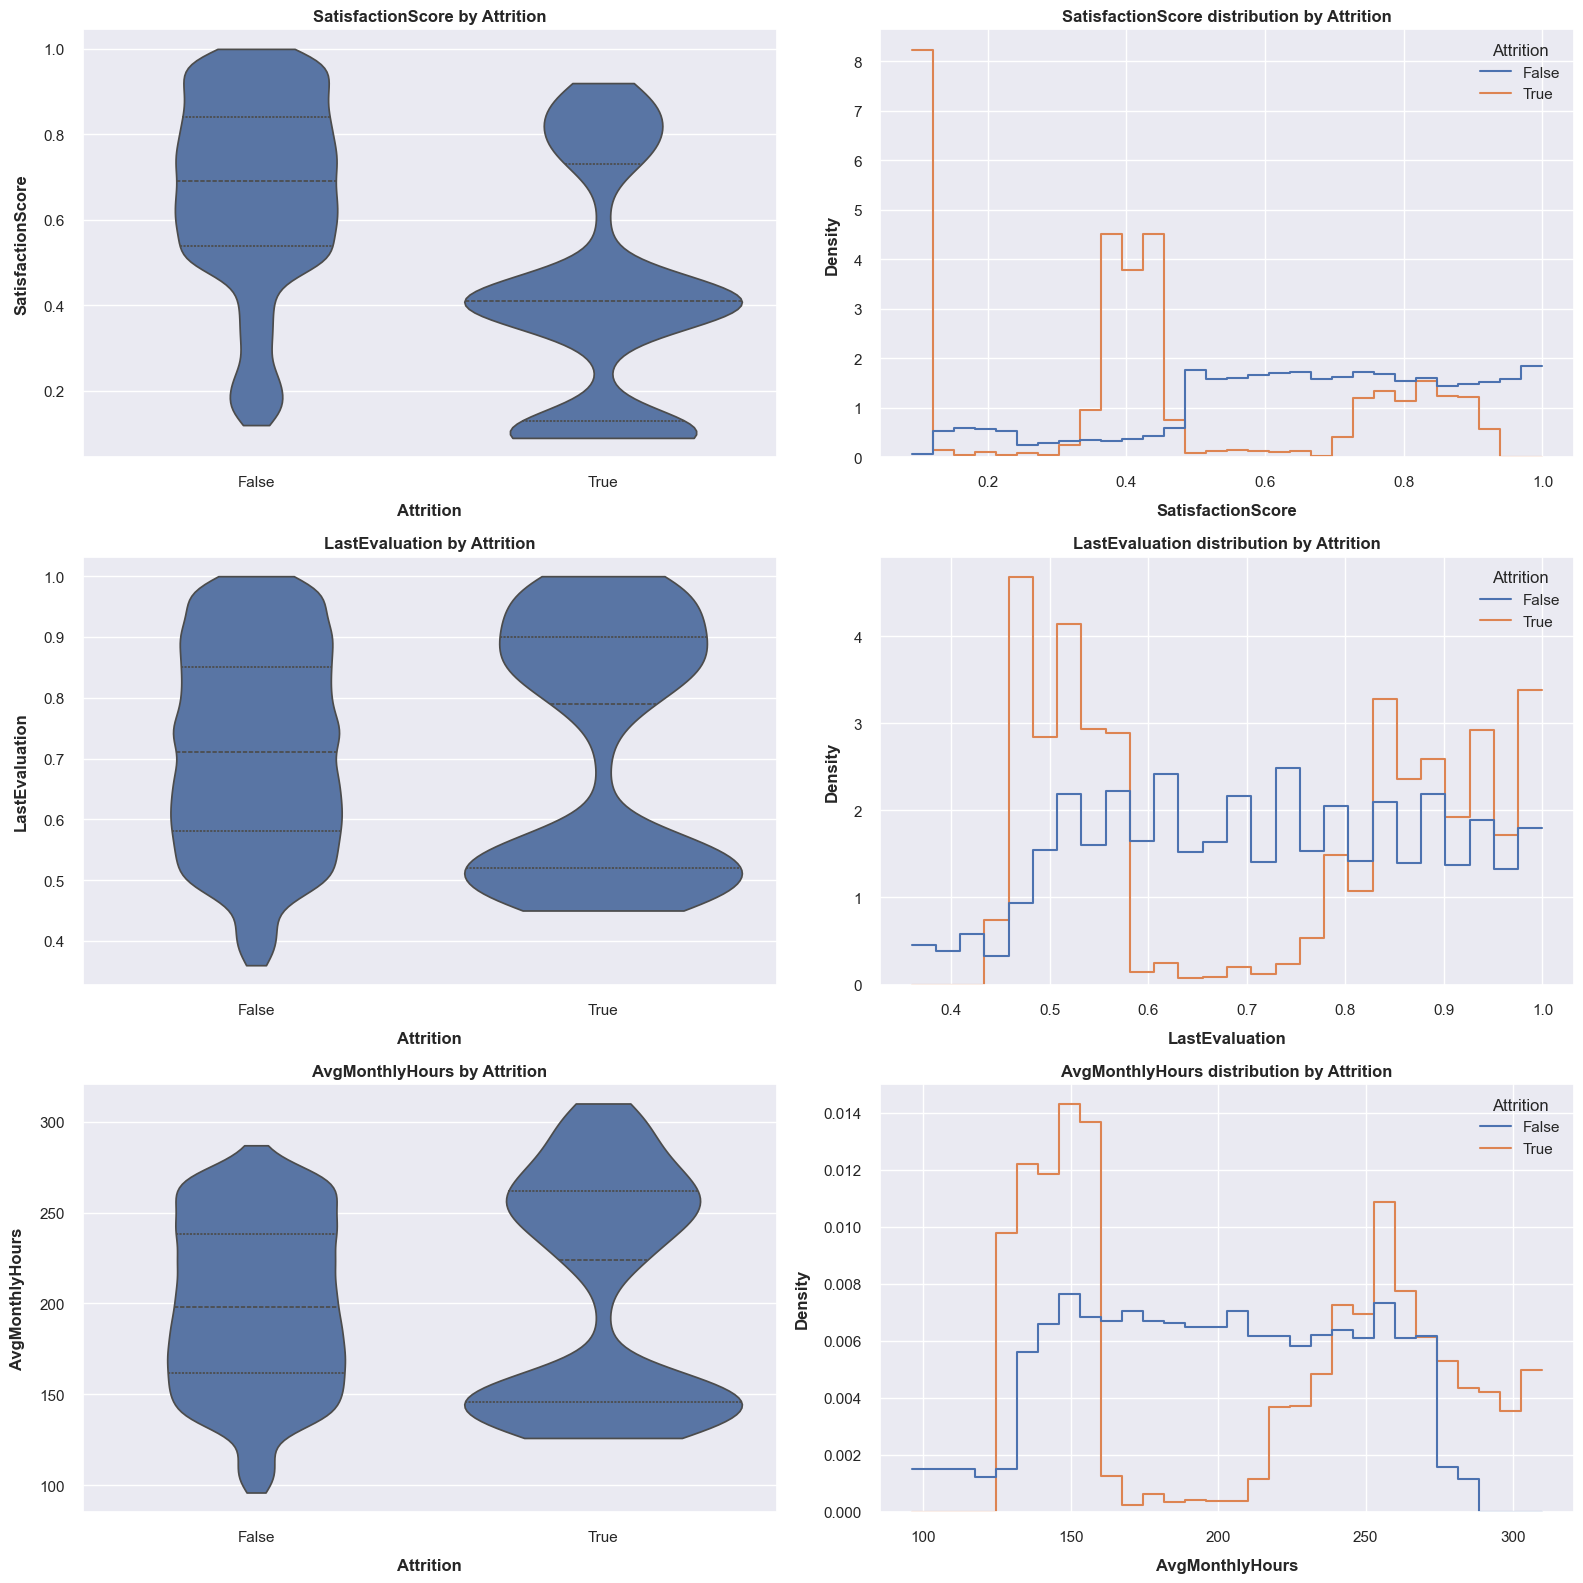

In [18]:
continuous_features = ["SatisfactionScore", "LastEvaluation", "AvgMonthlyHours"]

fig, axes = plt.subplots(3, 2, figsize=(16, 16))

for row, col in enumerate(continuous_features):
    sns.violinplot(data=df, x="Attrition", y=col, inner="quartile", cut=0, ax=axes[row, 0])
    axes[row, 0].set_xlabel("Attrition", fontweight="bold", labelpad=10)
    axes[row, 0].set_ylabel(col, fontweight="bold", labelpad=10)
    axes[row, 0].set_title(f"{col} by Attrition", fontweight="bold")

    sns.histplot(data=df, x=col, hue="Attrition", stat="density", common_norm=False, element="step", fill=False, ax=axes[row, 1])
    axes[row, 1].set_xlabel(col, fontweight="bold", labelpad=10)
    axes[row, 1].set_ylabel("Density", fontweight="bold", labelpad=10)
    axes[row, 1].set_title(f"{col} distribution by Attrition", fontweight="bold")

plt.tight_layout()
plt.show()

This visualization hints that low performers are either fired or quit, while high performers also leave possibly to seek better further opportunities.

In [19]:
df.groupby("Attrition")[["SatisfactionScore", "LastEvaluation", "AvgMonthlyHours", "ActiveProjects", "YearsAtCompany"]].mean().round(3)

,SatisfactionScore,LastEvaluation,AvgMonthlyHours,ActiveProjects,YearsAtCompany
Attrition,,,,,
False,0.667,0.715,199.060,3.787,3.380
True,0.440,0.718,207.419,3.856,3.877


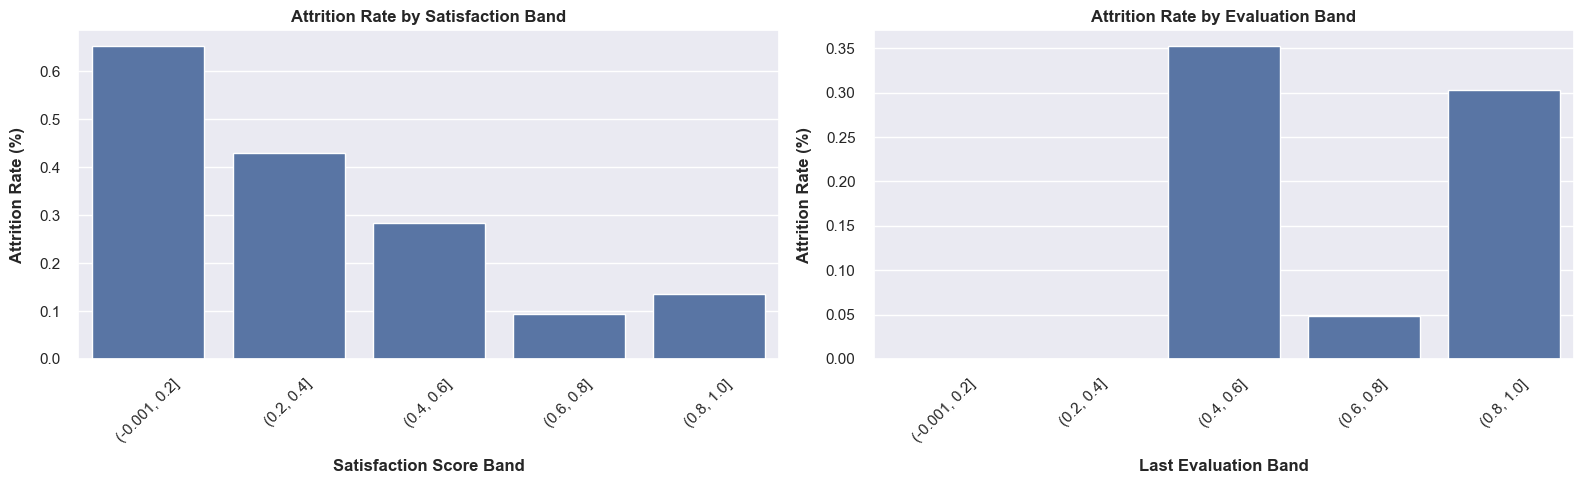

,SatisfactionBand,attrition_rate,sample_size
0,"(-0.001, 0.2]",0.65,1409
1,"(0.2, 0.4]",0.43,1506
2,"(0.4, 0.6]",0.28,3621
4,"(0.8, 1.0]",0.14,4224
3,"(0.6, 0.8]",0.09,4239


,EvaluationBand,attrition_rate,sample_size
1,"(0.4, 0.6]",0.35,4563
3,"(0.8, 1.0]",0.30,5740
2,"(0.6, 0.8]",0.05,4517
0,"(0.2, 0.4]",0.00,179


In [20]:
score_bins = pd.cut(df["SatisfactionScore"], bins=np.linspace(0, 1, 6), include_lowest=True)
evaluation_bins = pd.cut(df["LastEvaluation"], bins=np.linspace(0, 1, 6), include_lowest=True)

score_summary = attrition_summary(df.assign(SatisfactionBand=score_bins), "SatisfactionBand")
evaluation_summary = attrition_summary(df.assign(EvaluationBand=evaluation_bins), "EvaluationBand")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.barplot(data=score_summary, x="SatisfactionBand", y="attrition_rate", ax=axes[0])
sns.barplot(data=evaluation_summary, x="EvaluationBand", y="attrition_rate", ax=axes[1])

axes[0].tick_params(axis="x", rotation=45)
axes[1].tick_params(axis="x", rotation=45)
axes[0].set_title("Attrition Rate by Satisfaction Band", fontweight="bold")
axes[1].set_title("Attrition Rate by Evaluation Band", fontweight="bold")

for ax, xlabel in zip(axes, ["Satisfaction Score Band", "Last Evaluation Band"]):
    ax.set_xlabel(xlabel, fontweight="bold", labelpad=10)
    ax.set_ylabel("Attrition Rate (%)", fontweight="bold", labelpad=10)

plt.tight_layout()
plt.show()

display(score_summary.round(2))
display(evaluation_summary.round(2))

Satisfaction shows the strongest monotonic signal, while evaluation and workload-related features look more nonlinear. That combination is a good sign that tree-based models or interaction-aware models may capture useful structure even when simple linear summaries look modest.


### Relationships And Modeling Implications


**Encode booleans and ordered salary for a linear-signal view**


In [21]:
df_encoded = df.copy()

df_encoded[["WorkAccidents", "ReceivedPromotion", "Attrition"]] = df_encoded[["WorkAccidents", "ReceivedPromotion", "Attrition"]].astype(np.uint8)
df_encoded.Salary = df_encoded.Salary.map({"low": 0.0, "medium": 0.5, "high": 1}).astype(np.float32)

correlation_features = [
    "Salary",
    "ActiveProjects",
    "AvgMonthlyHours",
    "YearsAtCompany",
    "WorkAccidents",
    "ReceivedPromotion",
    "LastEvaluation",
    "SatisfactionScore",
    "Attrition",
]

corr = df_encoded[correlation_features].corr()

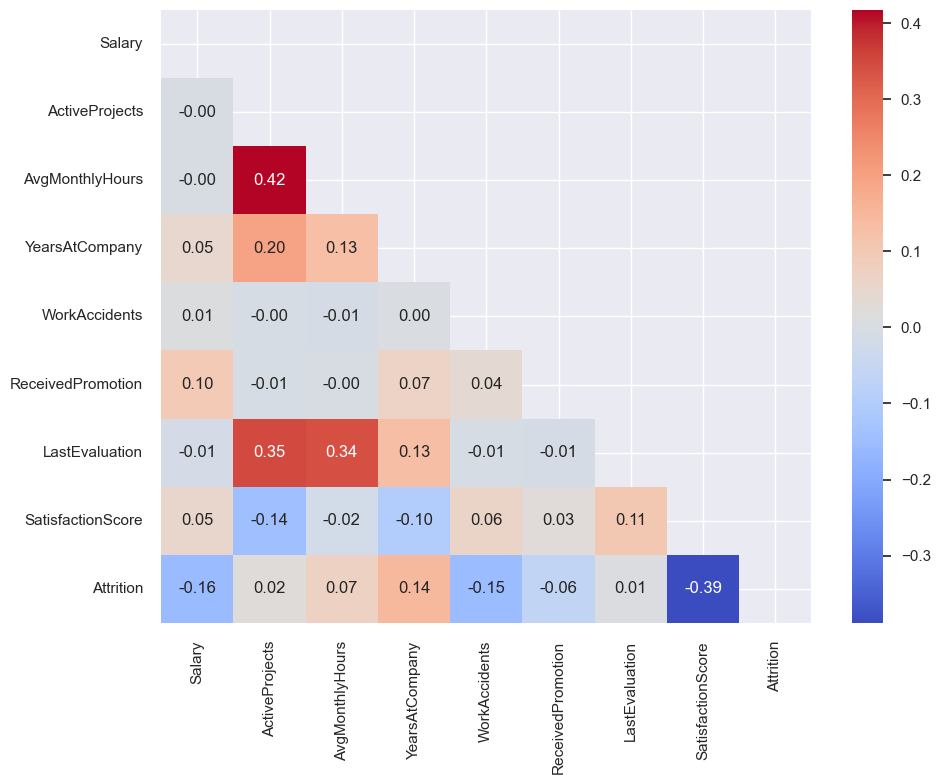

In [22]:
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(10, 8))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm")
plt.tight_layout()
plt.show()

Several features have modest Pearson correlation with attrition while still showing clear differences in attrition rate across categories or bins. Department is intentionally excluded here because integer encoding would create artificial distances between nominal categories.

The main modeling implication is that prediction may be feasible through nonlinear splits and interactions, even if a purely linear model under-reads the dataset. In particular, `satisfaction`, `compensation`, `tenure`, `promotion` history, `project` load, and `evaluation` shape all look like plausible contributors. `Department` also gives some insight, as we can see that attrition is considerably higher in some departments compared to others.

### EDA Takeaways


- `SatisfactionScore` is the strongest single signal and declines sharply among employees who leave.
- `Salary`, `ReceivedPromotion`, `WorkAccidents`, `ActiveProjects`, and `YearsAtCompany` also show meaningful separation once attrition is analyzed directly.
- Several relationships appear nonlinear, especially for evaluation, tenure, and project load, so correlation alone understates the available signal.
- Exact 0% and 100% attrition pockets suggest possible synthetic-data artifacts or unusually clean labeling - it may not reflect faithfully a real-world scenario.
- For modeling, stratified splits and class-sensitive metrics still matter, but the bigger opportunity is using models that can capture thresholds and interactions.

In [23]:
df_encoded.to_parquet(
    f"{PROCESSED_DATA_PATH}/employee_attrition_encoded.parquet",
    engine="pyarrow"
)